# 02 — Accuracy by Backend & LLM

Compares generation accuracy across retrieval backends (zero_shot, bm25_plus, ivfpq_low, ivfpq_high), LLMs (neo, qwen), context sizes (top1, top3), and evaluators (substring, binary_mistral).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent.parent))
from notebooks.full_pipe_eval.shared_setup import *

Loading results from: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/all_qa_8k
  ✓ neo | zero_shot | substring: 6,968 rows
  ✓ neo | zero_shot | binary_mistral: 6,968 rows
  ✓ neo | bm25_plus top1 | substring: 512 rows
  ✓ neo | bm25_plus top1 | binary_mistral: 512 rows
  ✓ neo | bm25_plus top3 | substring: 6,968 rows
  ✓ neo | bm25_plus top3 | binary_mistral: 6,968 rows
  ✓ neo | ivfpq_low top1 | substring: 6,968 rows
  ✓ neo | ivfpq_low top1 | binary_mistral: 6,968 rows
  ✓ neo | ivfpq_low top3 | substring: 6,968 rows
  ✓ neo | ivfpq_low top3 | binary_mistral: 6,968 rows
  ✓ neo | ivfpq_high top1 | substring: 6,968 rows
  ✓ neo | ivfpq_high top1 | binary_mistral: 6,968 rows
  ✓ neo | ivfpq_high top3 | substring: 6,968 rows
  ✓ neo | ivfpq_high top3 | binary_mistral: 6,968 rows
  ✓ qwen | zero_shot | substring: 6,968 rows
  ✓ qwen | zero_shot | binary_mistral: 6,968 rows
  ✓ qwen | bm25_plus top1 | substring: 6,968 rows
  ✓ qwen | bm25_plus top1 | binary_mistral: 6,968 ro

## 1. Overall accuracy bar chart — all backends × LLMs

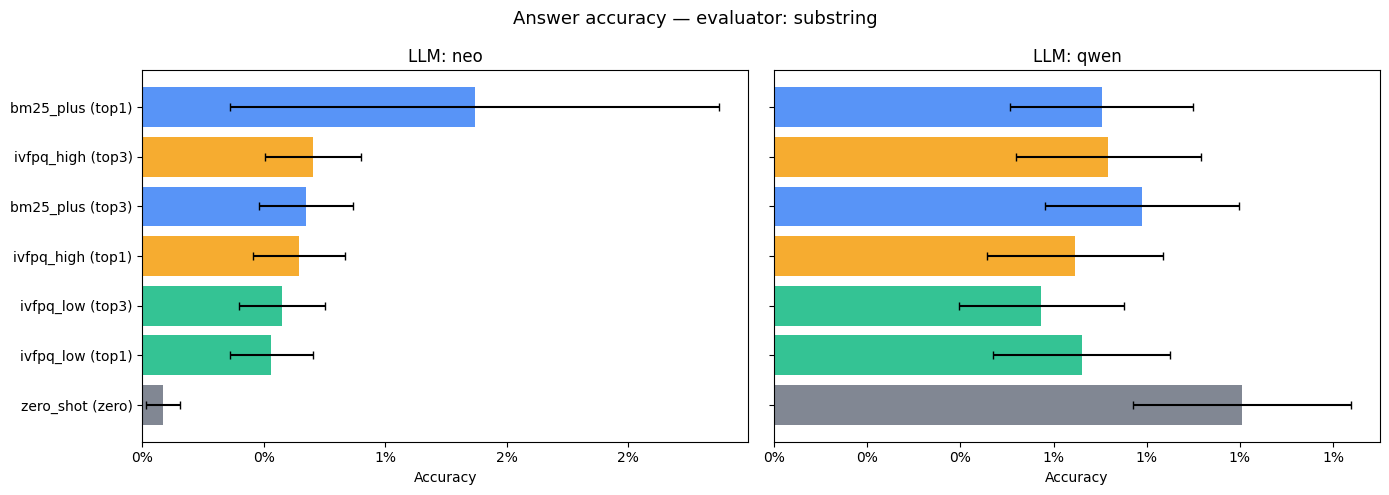

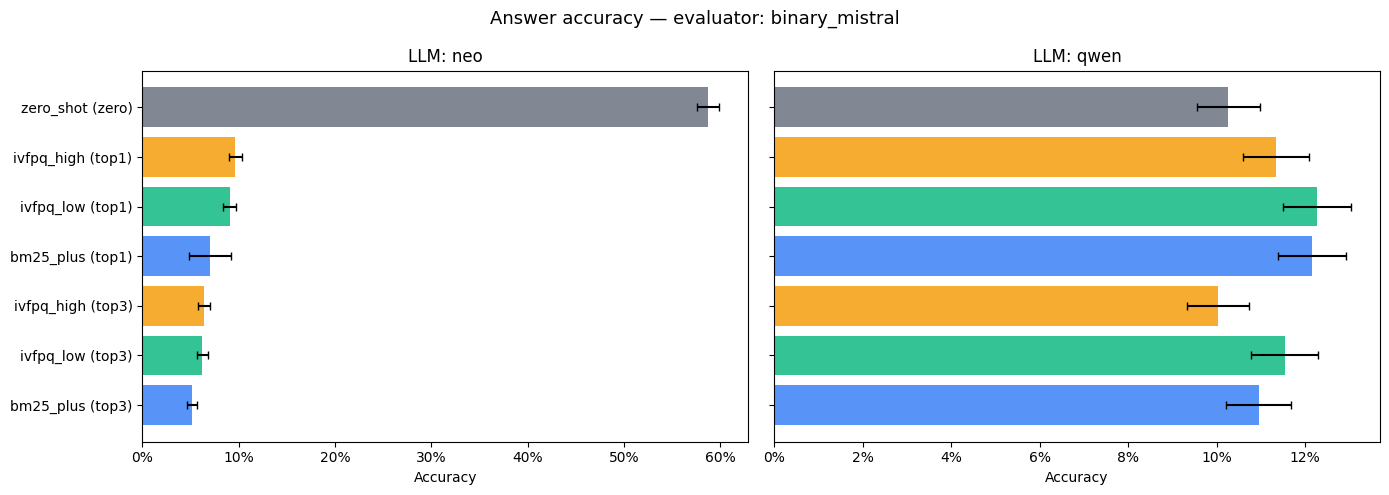

In [2]:
for ev in EVALUATOR_KEYS:
    df_plot = (
        results_all[results_all['evaluator'] == ev]
        .groupby(['llm', 'backend', 'ctx_label'])['evaluation_score']
        .agg(accuracy='mean', count='count', se=lambda x: x.sem())
        .reset_index()
    )
    df_plot['run_label'] = df_plot.apply(
        lambda r: f"{r['backend']} ({r['ctx_label']})", axis=1
    )
    df_plot['ci95'] = 1.96 * df_plot['se']

    fig, axes = plt.subplots(1, len(LLM_KEYS), figsize=(7 * len(LLM_KEYS), 5), sharey=True)
    if len(LLM_KEYS) == 1:
        axes = [axes]

    for ax, llm in zip(axes, LLM_KEYS):
        sub = df_plot[df_plot['llm'] == llm].sort_values('accuracy', ascending=True)
        colors = [backend_color(b) for b in sub['backend']]
        bars = ax.barh(sub['run_label'], sub['accuracy'], xerr=sub['ci95'],
                       color=colors, alpha=0.85, capsize=3)
        ax.set_xlabel('Accuracy')
        ax.set_title(f'LLM: {llm}')
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
        ax.axvline(0, color='black', linewidth=0.5)

    fig.suptitle(f'Answer accuracy — evaluator: {ev}', fontsize=13)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / f'accuracy_by_backend_{ev}.png', bbox_inches='tight', dpi=150)
    plt.show()

## 2. Zero-shot vs retrieval-augmented gap

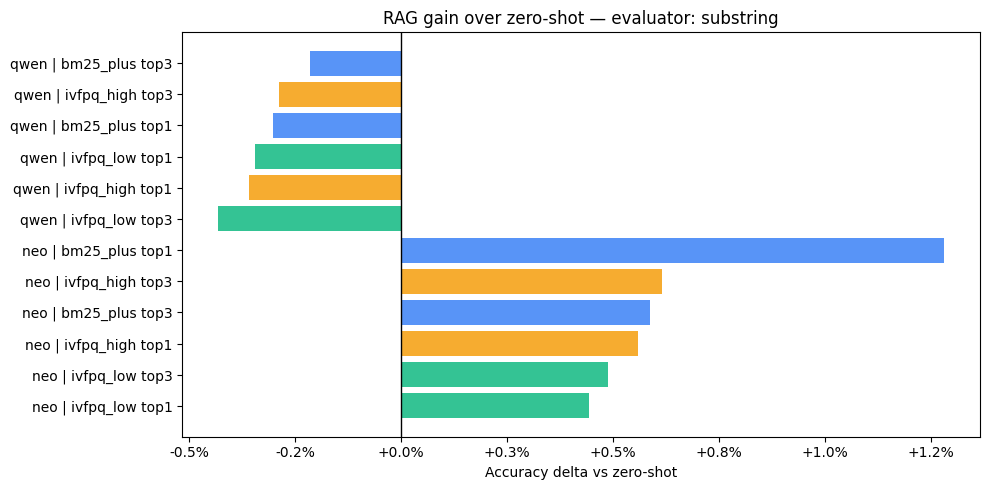

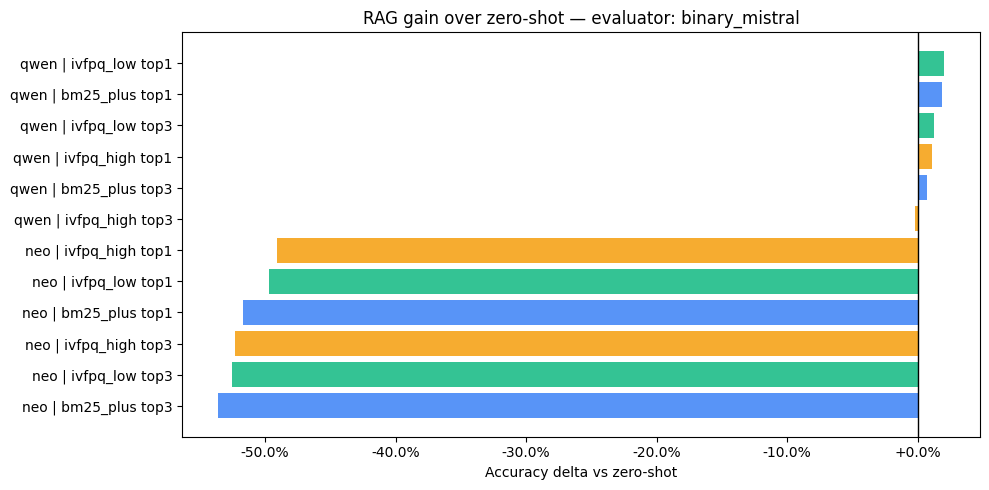

In [3]:
for ev in EVALUATOR_KEYS:
    zs = (
        results_all[
            (results_all['evaluator'] == ev) &
            (results_all['backend'] == 'zero_shot')
        ]
        .groupby('llm')['evaluation_score'].mean()
        .rename('zero_shot')
    )

    rag = (
        results_all[
            (results_all['evaluator'] == ev) &
            (results_all['backend'] != 'zero_shot')
        ]
        .groupby(['llm', 'backend', 'ctx_label'])['evaluation_score'].mean()
        .reset_index()
        .rename(columns={'evaluation_score': 'rag_accuracy'})
    )
    rag = rag.merge(zs, on='llm')
    rag['delta'] = rag['rag_accuracy'] - rag['zero_shot']

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, (llm, grp) in enumerate(rag.groupby('llm')):
        grp = grp.sort_values('delta')
        labels = grp.apply(lambda r: f"{r['backend']} {r['ctx_label']}", axis=1)
        ax.barh(
            [f"{llm} | {l}" for l in labels],
            grp['delta'],
            color=[backend_color(b) for b in grp['backend']],
            alpha=0.85,
        )
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel('Accuracy delta vs zero-shot')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.1%}'))
    ax.set_title(f'RAG gain over zero-shot — evaluator: {ev}')
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / f'rag_gain_{ev}.png', bbox_inches='tight', dpi=150)
    plt.show()

## 3. Evaluator agreement — substring vs binary_mistral

In [4]:
if 'substring' in EVALUATOR_KEYS and 'binary_mistral' in EVALUATOR_KEYS:
    sub_ss = results_all[results_all['evaluator'] == 'substring'][['llm','backend','ctx_label','id','evaluation_score']].rename(columns={'evaluation_score': 'substring'})
    sub_bm = results_all[results_all['evaluator'] == 'binary_mistral'][['llm','backend','ctx_label','id','evaluation_score']].rename(columns={'evaluation_score': 'binary_mistral'})
    merged = sub_ss.merge(sub_bm, on=['llm','backend','ctx_label','id'], how='inner')

    agreement = (
        merged.groupby(['llm','backend','ctx_label'])
        .apply(lambda g: (g['substring'] == g['binary_mistral']).mean())
        .reset_index(name='agreement')
    )
    print("Evaluator agreement (substring == binary_mistral):")
    print(agreement.to_string(index=False))

    # Cases where binary says correct but substring missed
    false_neg = merged[(merged['substring'] == False) & (merged['binary_mistral'] == True)]
    print(f"\nSubstring false negatives (binary=True, substring=False): {len(false_neg):,} ({len(false_neg)/len(merged):.1%})")
    if len(false_neg) > 0:
        print(false_neg[['llm','backend','ctx_label']].value_counts().head(10))
else:
    print('Need both substring and binary_mistral evaluators loaded.')

Evaluator agreement (substring == binary_mistral):
 llm    backend ctx_label  agreement
 neo  bm25_plus      top1   0.936293
 neo  bm25_plus      top3   0.945788
 neo ivfpq_high      top1   0.903397
 neo ivfpq_high      top3   0.933424
 neo  ivfpq_low      top1   0.908288
 neo  ivfpq_low      top3   0.936005
 neo  zero_shot      zero   0.421196
qwen  bm25_plus      top1   0.877989
qwen  bm25_plus      top3   0.888451
qwen ivfpq_high      top1   0.884783
qwen ivfpq_high      top3   0.896467
qwen  ivfpq_low      top1   0.874728
qwen  ivfpq_low      top3   0.882745
qwen  zero_shot      zero   0.894837

Substring false negatives (binary=True, substring=False): 12,519 (13.0%)
llm   backend     ctx_label
neo   zero_shot   zero         4259
qwen  ivfpq_low   top1          888
      bm25_plus   top1          869
      ivfpq_low   top3          836
      ivfpq_high  top1          814
      bm25_plus   top3          785
      zero_shot   zero          733
      ivfpq_high  top3          725
neo 

## 4. Per-dataset accuracy breakdown

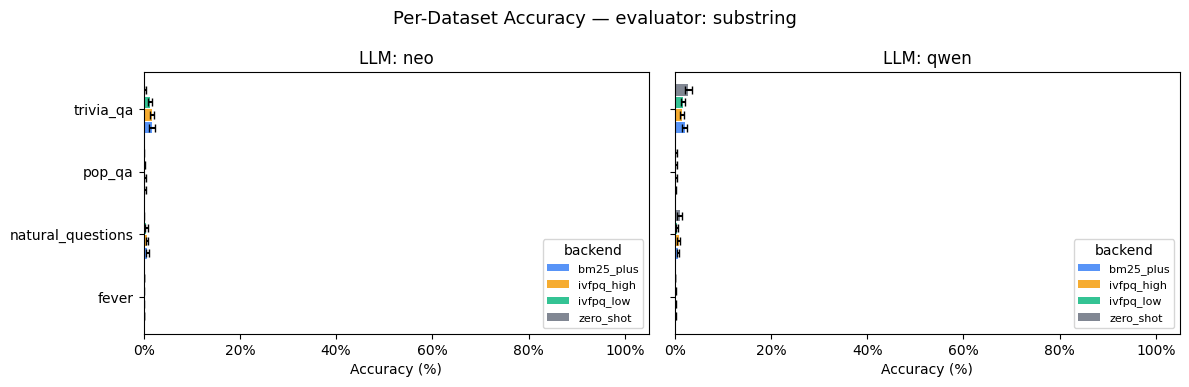


=== neo / substring ===
backend           bm25_plus ivfpq_high ivfpq_low zero_shot
dataset                                                   
fever                  0.0%       0.0%      0.1%      0.0%
natural_questions      0.8%       0.7%      0.6%      0.1%
pop_qa                 0.3%       0.3%      0.2%      0.1%
trivia_qa              1.8%       1.7%      1.4%      0.2%

=== qwen / substring ===
backend           bm25_plus ivfpq_high ivfpq_low zero_shot
dataset                                                   
fever                  0.1%       0.1%      0.1%      0.0%
natural_questions      0.7%       0.8%      0.5%      1.0%
pop_qa                 0.2%       0.3%      0.3%      0.2%
trivia_qa              2.0%       1.6%      1.6%      2.9%


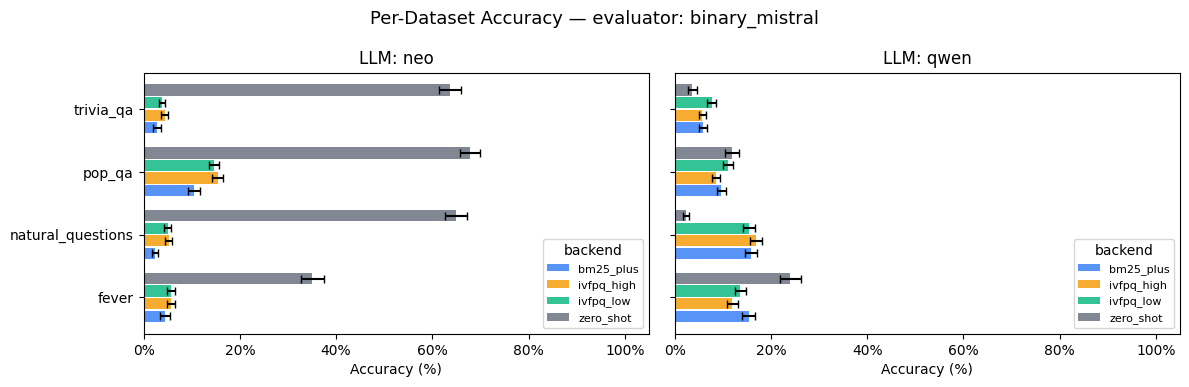


=== neo / binary_mistral ===
backend           bm25_plus ivfpq_high ivfpq_low zero_shot
dataset                                                   
fever                  4.5%       5.7%      5.7%     35.1%
natural_questions      2.3%       5.2%      5.0%     64.9%
pop_qa                10.5%      15.4%     14.6%     67.8%
trivia_qa              2.8%       4.4%      3.8%     63.6%

=== qwen / binary_mistral ===
backend           bm25_plus ivfpq_high ivfpq_low zero_shot
dataset                                                   
fever                 15.3%      11.9%     13.6%     24.0%
natural_questions     15.8%      16.9%     15.4%      2.3%
pop_qa                 9.7%       8.5%     11.1%     11.9%
trivia_qa              5.9%       5.8%      7.6%      3.6%


In [5]:
import matplotlib.ticker as mticker

for ev in EVALUATOR_KEYS:
    df_ev = results_all[results_all['evaluator'] == ev].copy()

    if 'dataset' not in df_ev.columns:
        print(f"[{ev}] No 'dataset' column — skipping §4.")
        continue

    datasets = sorted(df_ev['dataset'].dropna().unique())
    if len(datasets) <= 1:
        print(f"[{ev}] Only one dataset ({datasets[0] if datasets else '?'}) — skipping grouped chart.")
        continue

    ds_rows = []
    for llm in LLM_KEYS:
        for backend in BACKEND_KEYS:
            sub_lb = df_ev[(df_ev['llm'] == llm) & (df_ev['backend'] == backend)]
            for ds in datasets:
                sub = sub_lb[sub_lb['dataset'] == ds]
                n = len(sub)
                if n == 0:
                    continue
                acc = sub['evaluation_score'].mean()
                se  = (acc * (1 - acc) / n) ** 0.5
                ds_rows.append({'llm': llm, 'backend': backend, 'dataset': ds,
                                'n': n, 'accuracy': acc, 'ci95': 1.96 * se})
    ds_df = pd.DataFrame(ds_rows)

    n_llm = len(LLM_KEYS)
    fig, axes = plt.subplots(1, n_llm, figsize=(6 * n_llm, max(3, len(datasets) * 0.6 + 1.5)),
                             sharey=True)
    if n_llm == 1:
        axes = [axes]

    for ax, llm in zip(axes, LLM_KEYS):
        sub = ds_df[ds_df['llm'] == llm]
        pivot = sub.pivot_table(index='dataset', columns='backend', values='accuracy')
        ci_piv = sub.pivot_table(index='dataset', columns='backend', values='ci95')

        x = np.arange(len(pivot))
        backends_present = pivot.columns.tolist()
        w = 0.8 / max(len(backends_present), 1)
        offsets = np.linspace(-(len(backends_present)-1)/2*w, (len(backends_present)-1)/2*w, len(backends_present))

        for off, bk in zip(offsets, backends_present):
            vals = pivot[bk].values * 100
            errs = ci_piv[bk].values * 100
            ax.barh(x + off, vals, height=w * 0.9,
                    xerr=errs, capsize=3,
                    color=backend_color(bk), alpha=0.85, label=bk)

        ax.set_yticks(x)
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel('Accuracy (%)')
        ax.xaxis.set_major_formatter(mticker.PercentFormatter())
        ax.set_xlim(0, 105)
        ax.set_title(f'LLM: {llm}')
        ax.legend(title='backend', fontsize=8, loc='lower right')

    fig.suptitle(f'Per-Dataset Accuracy — evaluator: {ev}', fontsize=13)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / f'accuracy_by_dataset_{ev}.png', bbox_inches='tight', dpi=150)
    plt.show()

    # Pivot table display
    for llm in LLM_KEYS:
        sub = ds_df[ds_df['llm'] == llm]
        piv = sub.pivot_table(index='dataset', columns='backend', values='accuracy')
        print(f"\n=== {llm} / {ev} ===")
        print(piv.applymap(lambda v: f'{v:.1%}' if pd.notna(v) else '—').to_string())


## 5. Correct vs Incorrect distribution per backend

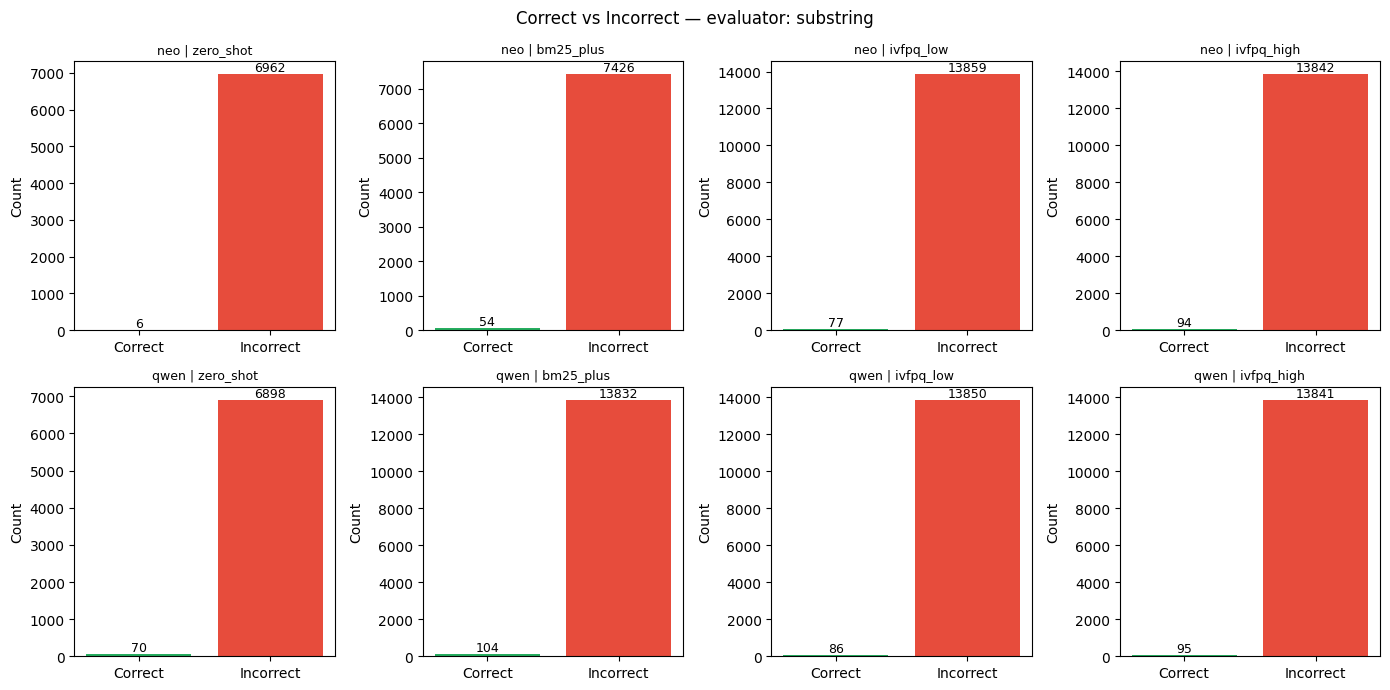

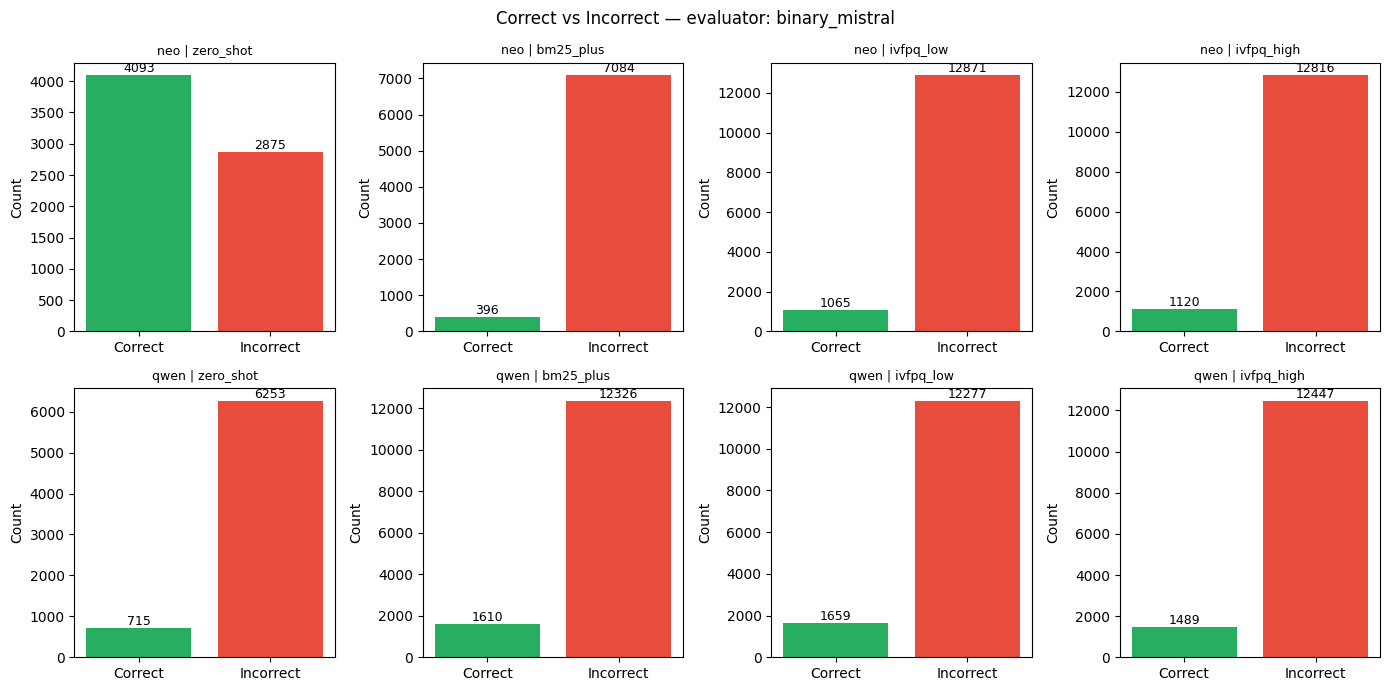

In [6]:
for ev in EVALUATOR_KEYS:
    df_ev = results_all[results_all['evaluator'] == ev].copy()
    runs = [(llm, bk) for llm in LLM_KEYS for bk in BACKEND_KEYS
            if not df_ev[(df_ev['llm']==llm) & (df_ev['backend']==bk)].empty]
    if not runs:
        continue

    ncols = min(4, len(runs))
    nrows = int(np.ceil(len(runs) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(3.5 * ncols, 3.5 * nrows), squeeze=False)

    for idx, (llm, bk) in enumerate(runs):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]
        sub = df_ev[(df_ev['llm'] == llm) & (df_ev['backend'] == bk)]
        correct   = int(sub['evaluation_score'].sum())
        incorrect = len(sub) - correct
        ax.bar(['Correct', 'Incorrect'], [correct, incorrect],
               color=['#27ae60', '#e74c3c'])
        ax.set_title(f'{llm} | {bk}', fontsize=9)
        ax.set_ylabel('Count')
        for i, v in enumerate([correct, incorrect]):
            ax.text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=9)

    for idx in range(len(runs), nrows * ncols):
        r, c = divmod(idx, ncols)
        axes[r][c].axis('off')

    fig.suptitle(f'Correct vs Incorrect — evaluator: {ev}', fontsize=12)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / f'score_distribution_{ev}.png', bbox_inches='tight', dpi=150)
    plt.show()


## 6. Cross-backend agreement — per LLM

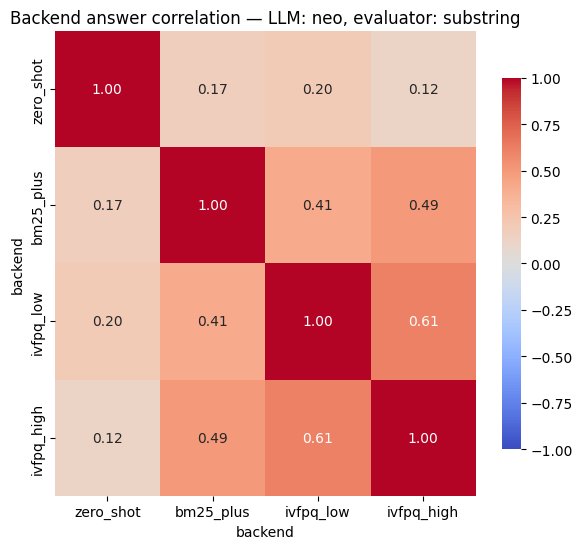


=== Backend pair agreement — neo / substring ===
  zero_shot vs bm25_plus: agree=99.2%  both=0.0%  only_zero_shot=0.0%  only_bm25_plus=0.7%  neither=99.2%  (n=6,828)
  zero_shot vs ivfpq_low: agree=99.5%  both=0.0%  only_zero_shot=0.0%  only_ivfpq_low=0.5%  neither=99.4%  (n=6,828)
  zero_shot vs ivfpq_high: agree=99.3%  both=0.0%  only_zero_shot=0.1%  only_ivfpq_high=0.6%  neither=99.3%  (n=6,828)
  bm25_plus vs ivfpq_low: agree=99.2%  both=0.3%  only_bm25_plus=0.5%  only_ivfpq_low=0.3%  neither=99.0%  (n=6,828)
  bm25_plus vs ivfpq_high: agree=99.3%  both=0.4%  only_bm25_plus=0.4%  only_ivfpq_high=0.3%  neither=98.9%  (n=6,828)
  ivfpq_low vs ivfpq_high: agree=99.5%  both=0.4%  only_ivfpq_low=0.2%  only_ivfpq_high=0.3%  neither=99.2%  (n=6,828)


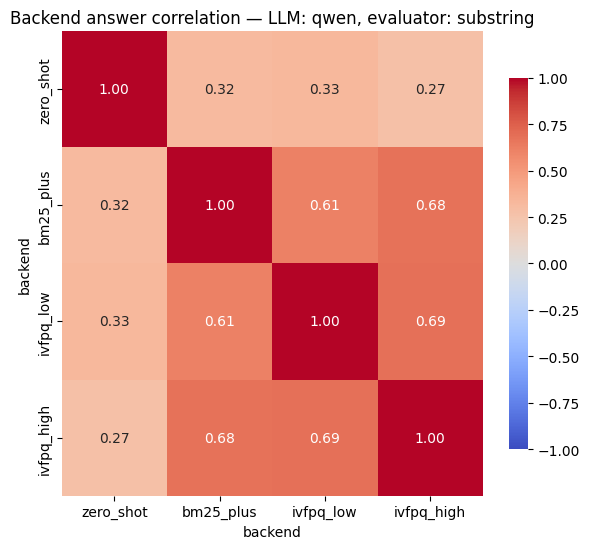


=== Backend pair agreement — qwen / substring ===
  zero_shot vs bm25_plus: agree=98.9%  both=0.3%  only_zero_shot=0.7%  only_bm25_plus=0.5%  neither=98.6%  (n=6,828)
  zero_shot vs ivfpq_low: agree=98.9%  both=0.3%  only_zero_shot=0.7%  only_ivfpq_low=0.4%  neither=98.7%  (n=6,828)
  zero_shot vs ivfpq_high: agree=98.8%  both=0.2%  only_zero_shot=0.7%  only_ivfpq_high=0.4%  neither=98.6%  (n=6,828)
  bm25_plus vs ivfpq_low: agree=99.5%  both=0.4%  only_bm25_plus=0.3%  only_ivfpq_low=0.2%  neither=99.0%  (n=6,828)
  bm25_plus vs ivfpq_high: agree=99.6%  both=0.5%  only_bm25_plus=0.2%  only_ivfpq_high=0.2%  neither=99.1%  (n=6,828)
  ivfpq_low vs ivfpq_high: agree=99.6%  both=0.5%  only_ivfpq_low=0.2%  only_ivfpq_high=0.2%  neither=99.1%  (n=6,828)


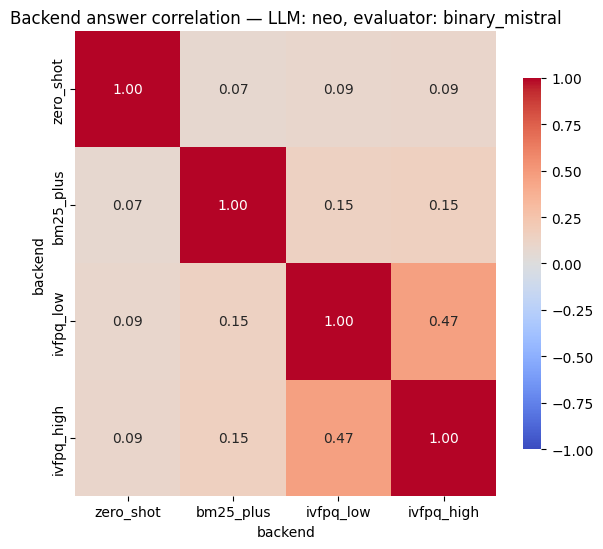


=== Backend pair agreement — neo / binary_mistral ===
  zero_shot vs bm25_plus: agree=43.7%  both=4.1%  only_zero_shot=54.8%  only_bm25_plus=1.5%  neither=39.5%  (n=6,828)
  zero_shot vs ivfpq_low: agree=45.3%  both=6.7%  only_zero_shot=52.3%  only_ivfpq_low=2.4%  neither=38.6%  (n=6,828)
  zero_shot vs ivfpq_high: agree=45.5%  both=7.1%  only_zero_shot=51.8%  only_ivfpq_high=2.6%  neither=38.4%  (n=6,828)
  bm25_plus vs ivfpq_low: agree=88.2%  both=1.5%  only_bm25_plus=4.2%  only_ivfpq_low=7.6%  neither=86.7%  (n=6,828)
  bm25_plus vs ivfpq_high: agree=87.8%  both=1.6%  only_bm25_plus=4.0%  only_ivfpq_high=8.2%  neither=86.2%  (n=6,828)
  ivfpq_low vs ivfpq_high: agree=90.9%  both=4.9%  only_ivfpq_low=4.2%  only_ivfpq_high=4.9%  neither=86.0%  (n=6,828)


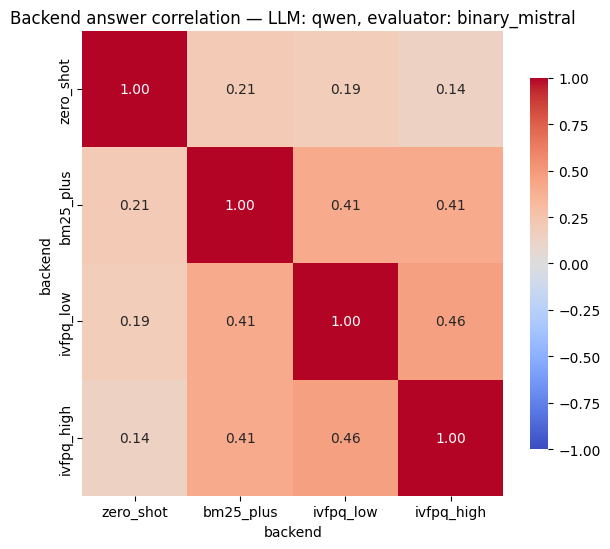


=== Backend pair agreement — qwen / binary_mistral ===
  zero_shot vs bm25_plus: agree=84.2%  both=3.3%  only_zero_shot=6.9%  only_bm25_plus=8.9%  neither=80.9%  (n=6,828)
  zero_shot vs ivfpq_low: agree=83.7%  both=3.1%  only_zero_shot=7.1%  only_ivfpq_low=9.2%  neither=80.6%  (n=6,828)
  zero_shot vs ivfpq_high: agree=83.3%  both=2.5%  only_zero_shot=7.8%  only_ivfpq_high=8.9%  neither=80.9%  (n=6,828)
  bm25_plus vs ivfpq_low: agree=87.3%  both=5.9%  only_bm25_plus=6.3%  only_ivfpq_low=6.4%  neither=81.4%  (n=6,828)
  bm25_plus vs ivfpq_high: agree=87.8%  both=5.7%  only_bm25_plus=6.5%  only_ivfpq_high=5.7%  neither=82.1%  (n=6,828)
  ivfpq_low vs ivfpq_high: agree=88.8%  both=6.2%  only_ivfpq_low=6.1%  only_ivfpq_high=5.2%  neither=82.6%  (n=6,828)


In [7]:
for ev in EVALUATOR_KEYS:
    df_ev = results_all[results_all['evaluator'] == ev].copy()

    id_col = 'id' if 'id' in df_ev.columns else 'question_id' if 'question_id' in df_ev.columns else None
    if id_col is None and 'question' in df_ev.columns:
        id_col = 'question'
    if id_col is None:
        print(f"[{ev}] Cannot identify question ID column — skipping §6.")
        continue

    for llm in LLM_KEYS:
        sub = df_ev[df_ev['llm'] == llm]
        bk_present = [b for b in BACKEND_KEYS if not sub[sub['backend']==b].empty]
        if len(bk_present) < 2:
            continue

        # Build pivot: rows=question_id, cols=backend, values=evaluation_score
        pivot = sub.pivot_table(index=id_col, columns='backend', values='evaluation_score', aggfunc='first')
        pivot = pivot[bk_present]

        # Correlation heatmap
        corr = pivot.corr()
        fig, ax = plt.subplots(figsize=(max(4, len(bk_present)*1.5), max(3.5, len(bk_present)*1.4)))
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                    vmin=-1, vmax=1, ax=ax, cbar_kws={'shrink': 0.8})
        ax.set_title(f'Backend answer correlation — LLM: {llm}, evaluator: {ev}')
        plt.tight_layout()
        plt.savefig(IMAGES_DIR / f'backend_agreement_corr_{llm}_{ev}.png', bbox_inches='tight', dpi=150)
        plt.show()

        # Pair-wise agreement table
        print(f"\n=== Backend pair agreement — {llm} / {ev} ===")
        for i, b1 in enumerate(bk_present):
            for b2 in bk_present[i+1:]:
                merged = pivot[[b1, b2]].dropna()
                if merged.empty:
                    continue
                agree = (merged[b1] == merged[b2]).mean()
                both  = ((merged[b1] == 1) & (merged[b2] == 1)).mean()
                only1 = ((merged[b1] == 1) & (merged[b2] == 0)).mean()
                only2 = ((merged[b1] == 0) & (merged[b2] == 1)).mean()
                neither = ((merged[b1] == 0) & (merged[b2] == 0)).mean()
                print(f"  {b1} vs {b2}: agree={agree:.1%}  both={both:.1%}  "
                      f"only_{b1}={only1:.1%}  only_{b2}={only2:.1%}  neither={neither:.1%}  "
                      f"(n={len(merged):,})")
